Subagents

A deep agent can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine (keeping the main agent’s context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor blocks until the subagent finishes. For long-running tasks, parallel workstreams, or cases where you need mid-flight steering and cancellation, see Async subagents.

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY4"]=os.getenv("OPENAI_API_KEY4")
os.environ["GROQ_API_KEY4"]=os.getenv("GROQ_API_KEY4")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

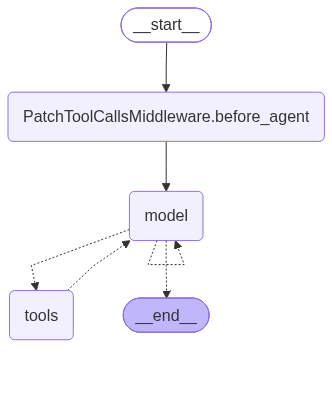

In [12]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,

):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )
research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:openai/gpt-oss-120b",  # Optional override, defaults to main agent model

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=subagents
)
agent

In [18]:
result = agent.invoke(
      {
          "messages": [{
              "role": "user",
              "content": "Research on deepagents topic.",       
          }],
          
      },
      config={"configurable": {"thread_id": "skills-demo"}},
  )

# Print the conversation so you can SEE the skill being triggered:
# look for a ToolMessage from `read_file` on the langgraph-docs SKILL.md.
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research on deepagents topic.
================================== Ai Message ==================================

Below is a curated overview of the research landscape around **deep agents** – autonomous agents that combine deep learning (often with reinforcement learning, language models, or multimodal perception) to act, reason, and adapt in complex environments. I’ve grouped the material into thematic sections, highlighted seminal and recent papers, and noted open challenges and promising directions.

---

## 1. What Are “Deep Agents”?

| Term | Typical Meaning | Core Components |
|------|----------------|-----------------|
| **Deep Reinforcement Learning (DRL) agents** | Agents that learn policies via trial‑and‑error using deep neural nets as function approximators. | Environment ↔ State → Neural Net (policy/value) → Action → Reward |
| **Large‑Scale Language Model (LLM) agents** | Agents that use LLMs 